In [1]:
from pathlib import Path

# Find repo root
REPO_ROOT = Path.cwd().parent
print(f"Repo root: {REPO_ROOT}")



Repo root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/DEDA Project/DEDA_LLM_Spatial_Hotelling


In [2]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

PATH_RAW = REPO_ROOT / Path('data/raw')

# Midpoint table (center coordinates)
zensus = pd.read_parquet(PATH_RAW / 'zensus2022_population_grid.parquet')
lor = gpd.read_parquet(PATH_RAW / 'lor_shapes.parquet')
berlin = gpd.read_file(PATH_RAW / 'city_boundary_Berlin.geojson')


In [3]:
import shapely.geometry

zensus["geometry"] = zensus.apply(lambda row: shapely.geometry.Point(row["lon"], row["lat"]), axis=1)

In [ ]:
zensus = gpd.GeoDataFrame(zensus, geometry="geometry", crs="EPSG:3035")

In [7]:
org = pd.read_csv("/Users/jedrek/Downloads/Zensus2022_Bevoelkerungszahl/Zensus2022_Bevoelkerungszahl_100m-Gitter.csv")

In [14]:
len(org)

3088037

In [13]:
(len(org)*10000)/10**6

30880.37

In [9]:
zensus

,lon,lat,Einwohner,geometry
0,4337050.0,2689150.0,4,POINT (4337050 2689150)
1,4341150.0,2689150.0,11,POINT (4341150 2689150)
2,4341250.0,2690850.0,4,POINT (4341250 2690850)
3,4341250.0,2691250.0,12,POINT (4341250 2691250)
4,4341250.0,2691350.0,3,POINT (4341250 2691350)
...,...,...,...,...
3088032,4220150.0,3547550.0,14,POINT (4220150 3547550)
3088033,4219850.0,3547650.0,4,POINT (4219850 3547650)
3088034,4219950.0,3547650.0,10,POINT (4219950 3547650)
3088035,4220050.0,3547650.0,3,POINT (4220050 3547650)


<Axes: >

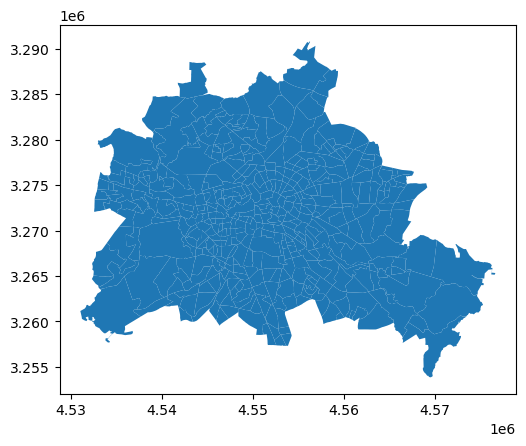

In [11]:
lor.plot()

<Axes: >

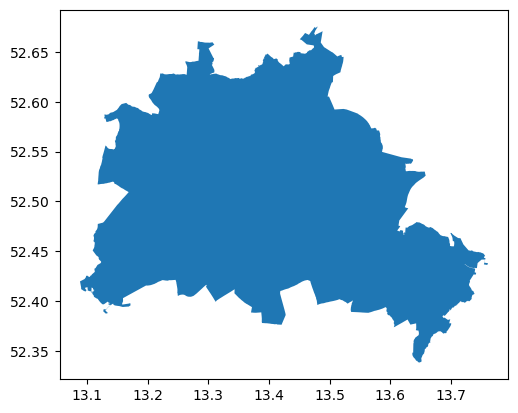

In [84]:
berlin.plot()

In [85]:
berlin = berlin.to_crs('EPSG:25833')

<Axes: >

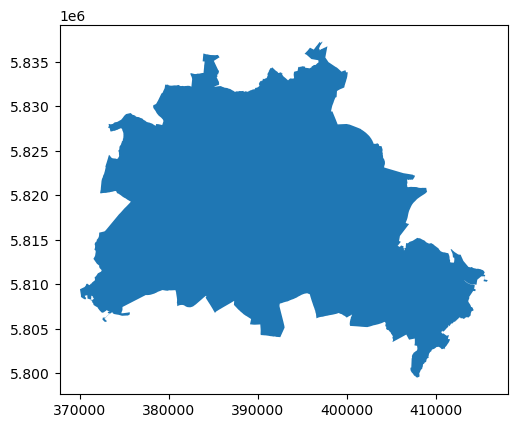

In [86]:
berlin.plot()

In [87]:
# Squares (100m x 100m) are precomputed in `zensus_grid`.
# We keep it as a GeoDataFrame with square polygon geometry.
zensus_gdf = zensus_grid

In [88]:
berlin = berlin.to_crs('EPSG:3035')
zensus_gdf = zensus_gdf.to_crs('EPSG:3035')

# Use vectorized spatial operation instead of loop
berlin_geom = berlin.unary_union  # Merge all Berlin geometries into one
berlin_gdf = zensus_gdf[zensus_gdf.geometry.centroid.within(berlin_geom)].copy()


/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_91388/1488505121.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  berlin_geom = berlin.unary_union  # Merge all Berlin geometries into one
